In [2]:
import setup
from src.utils.my_plotting import new_fig, finish_fig, plot_corr_mat

In [3]:
import polars as pl
from polars import col as c
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
INPUT = '../data/processed/features.parquet'

In [5]:
lf = pl.scan_parquet(INPUT).sort(['ticker', 'date'])

In [6]:
lf.describe()

statistic,ticker,date,open,high,low,close,volume,logret,mkt_logret,beta60,beta252,mom5,mom10,mom20,mom60,mom120,mom252,std5,std10,std20,std60,std120,std252,dollar_volume,log_adv5,log_adv10,log_adv20,log_adv60,log_adv120,log_adv252
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""2917517""","""2917517""",2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917016e6,2.917173e6,2.838791e6,2.593159e6,2.915012e6,2.912507e6,2.907501e6,2.887532e6,2.857592e6,2.791802e6,2.913008e6,2.908004e6,2.898014e6,2.858202e6,2.798955e6,2.670812e6,2.917517e6,2.915513e6,2.913008e6,2.908001e6,2.888031e6,2.858091e6,2.7923e6
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,501.0,344.0,78726.0,324358.0,2505.0,5010.0,10016.0,29985.0,59925.0,125715.0,4509.0,9513.0,19503.0,59315.0,118562.0,246705.0,0.0,2004.0,4509.0,9516.0,29486.0,59426.0,125217.0
"""mean""",null,"""2014-01-27 09:58:18.835345""",85.111451,86.11896,84.082275,74.978281,8.5368e6,0.000447,0.000447,2.266773,1.816046,1.84678,2.650198,2.126059,2.164116,2.193183,2.177633,0.018978,0.020318,0.021182,0.021957,0.022215,0.022377,2.7487e8,-inf,-inf,18.736041,18.765054,18.771621,18.77422
"""std""",null,null,198.358845,200.748997,195.980598,195.59945,4.7475e7,0.023507,0.012591,2.715245,1.517173,11.746078,23.965245,18.655814,20.959583,21.08268,20.531009,0.013926,0.011856,0.010203,0.008328,0.007555,0.006953,1.1689e9,NaN,NaN,1.028249,0.987159,0.977299,0.969489
"""min""","""A""","""2000-01-03""",0.030208,0.030521,0.026979,0.030521,0.0,-1.141076,-0.139258,-18.632108,-2.444451,-0.999637,-0.999633,-0.999625,-0.9996,-0.999617,-0.999637,0.0,0.0,0.000194,0.006121,0.007443,0.008687,0.0,-inf,-inf,6.318466,10.009207,11.97806,12.295934
"""25%""",null,"""2007-09-25""",23.629999,23.95652,23.299999,16.2519,953400.0,-0.009076,-0.004866,0.705436,0.777121,-0.667086,-0.574113,-0.581434,-0.532896,-0.538752,-0.556735,0.010413,0.012795,0.014477,0.016262,0.016934,0.017406,3.4015e7,17.850176,18.000314,18.053176,18.08506,18.091771,18.094133
"""50%""",null,"""2014-06-23""",45.66,46.189999,45.119999,34.29525,2.23771e6,0.000575,0.000871,1.491962,1.441042,0.293848,-0.107343,0.027752,-0.01212,-0.023404,-0.005143,0.015489,0.017447,0.018844,0.020256,0.020734,0.021061,9.4971e7,18.574706,18.632871,18.660151,18.679204,18.683067,18.686947
"""75%""",null,"""2020-08-19""",89.559998,90.540001,88.548111,77.082573,5.4445e6,0.010237,0.006397,2.819561,2.442105,1.89873,1.117597,1.390294,1.120843,1.122625,1.255793,0.023198,0.024376,0.025132,0.025745,0.025875,0.02591,2.2663e8,19.299329,19.309295,19.315337,19.323789,19.325436,19.327375
"""max""","""ZTS""","""2026-07-08""",9914.169922,9964.769531,9794.0,9924.400391,9.2309e9,0.704868,0.105833,131.184125,31.399031,2408.614778,3080.524331,2410.125416,2759.92759,2713.519567,3089.722544,0.516215,0.362556,0.257062,0.150632,0.108856,0.079717,1.5438e11,24.512566,24.182737,23.882009,23.604404,23.347213,23.236752


## Random ticker -  visual inspection

In [47]:
df = lf.filter(
    c('ticker').is_in( c('ticker').unique().sample(1).implode() )
).collect().to_pandas().set_index('date')

In [49]:
df = lf.filter(
    c('ticker') == 'AAPL'
).collect().to_pandas().set_index('date')

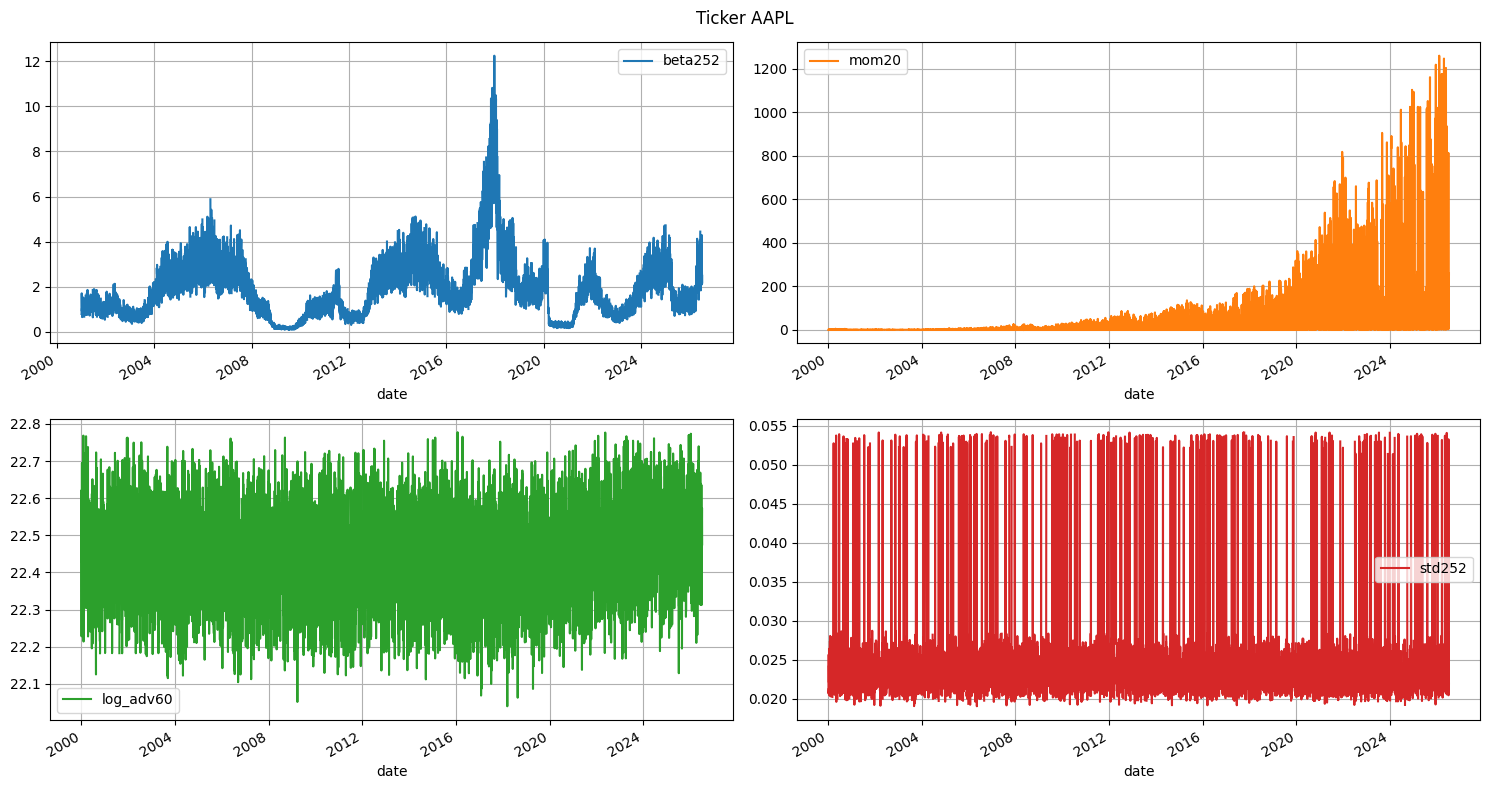

In [50]:
feat = 'beta252'
f, ax = plt.subplots(2, 2, figsize=(15, 8))
df.plot(y='beta252', ax=ax[0, 0])
df.plot(y='mom20', ax=ax[0, 1], color='C1')
df.plot(y='log_adv60', ax=ax[1, 0], color='C2')
df.plot(y='std252', ax=ax[1, 1], color='C3')
for ax__ in ax.flatten():
    ax__.grid()
f.suptitle('Ticker ' + df['ticker'].iloc[0])
plt.tight_layout()
# finish_fig(ax, yl=feat, title = df['ticker'].iloc[0] + ' - ' + feat)

## Null count

In [7]:
lf.null_count().collect()

ticker,date,open,high,low,close,volume,logret,mom5,mom10,mom20,mom60,mom120,mom252,std5,std10,std20,std60,std120,std252,dollar_volume,adv5,adv10,adv20,adv60,adv120,adv252
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,501,2505,5010,10016,29985,59925,125715,2004,4509,9516,29486,59426,125217,0,2004,4509,9516,29486,59426,125217


## Average number of observations per ticker

In [ ]:
lf.group_by('ticker').agg()

## Distributions

In [54]:
mom20 = ( 
    lf
    .select('mom20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
std20 = ( 
    lf
    .select('std20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
adv20 = ( 
    lf
    .select('log_adv20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
beta252 = ( 
    lf
    .select('beta252')
    .drop_nulls()
    .collect()
    .to_pandas()
)

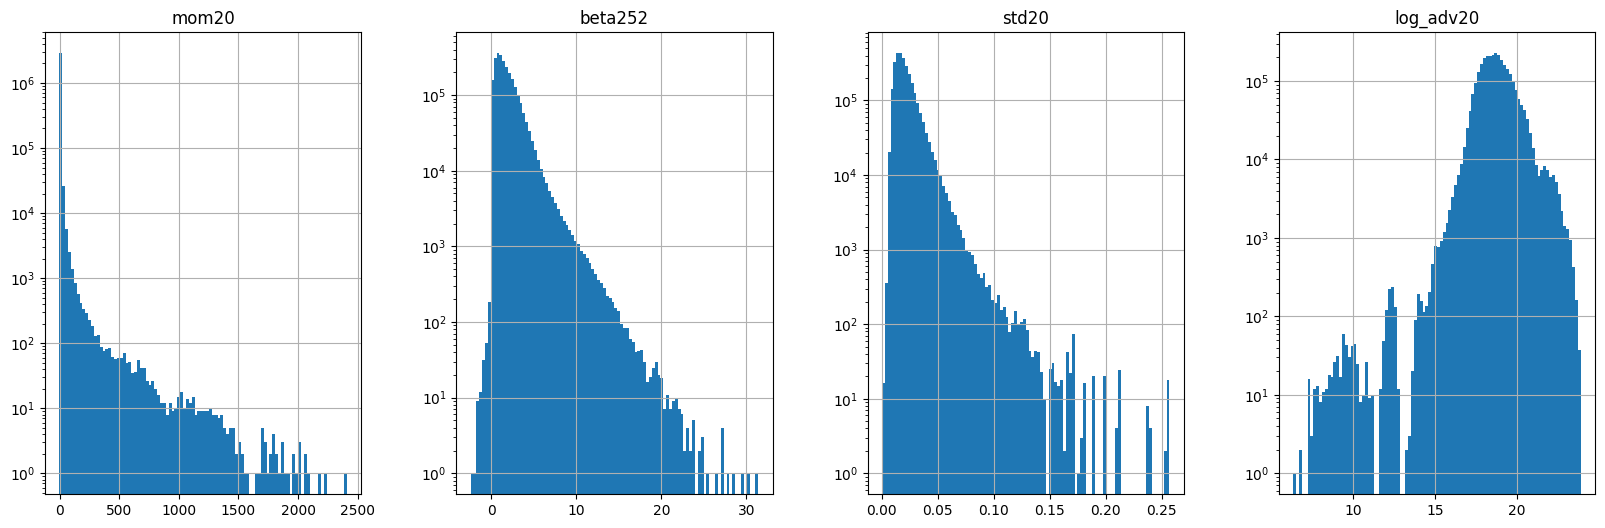

In [55]:
f, ax = plt.subplots(1, 4, figsize=(20, 6))
mom20.hist(bins=100, ax=ax[0], log=True)
beta252.hist(bins=100, ax=ax[1], log=True)
std20.hist(bins=100, ax=ax[2], log=True)
adv20.hist(bins=100, ax=ax[3], log=True);

In [8]:
feat = 'mom20'
(
    lf
    .select(
        c(feat).quantile(0.01).alias('Q1%'),
        c(feat).median().alias('median'),
        c(feat).quantile(0.99).alias('Q99%')
    )
    .collect()
)

Q1%,median,Q99%
f64,f64,f64
-0.252259,0.013358,0.293769


## Correlation

In [56]:
Cmat = (
    lf
    .select(['mom5', 'mom20', 'mom120', 'mom252', 
             'std5', 'std20', 'std120', 'std252', 
             'beta60', 'beta252',
             'log_adv5', 'log_adv20', 'log_adv120', 'log_adv252'])
    .drop_nulls()
    .collect()
    .to_pandas()
).corr()

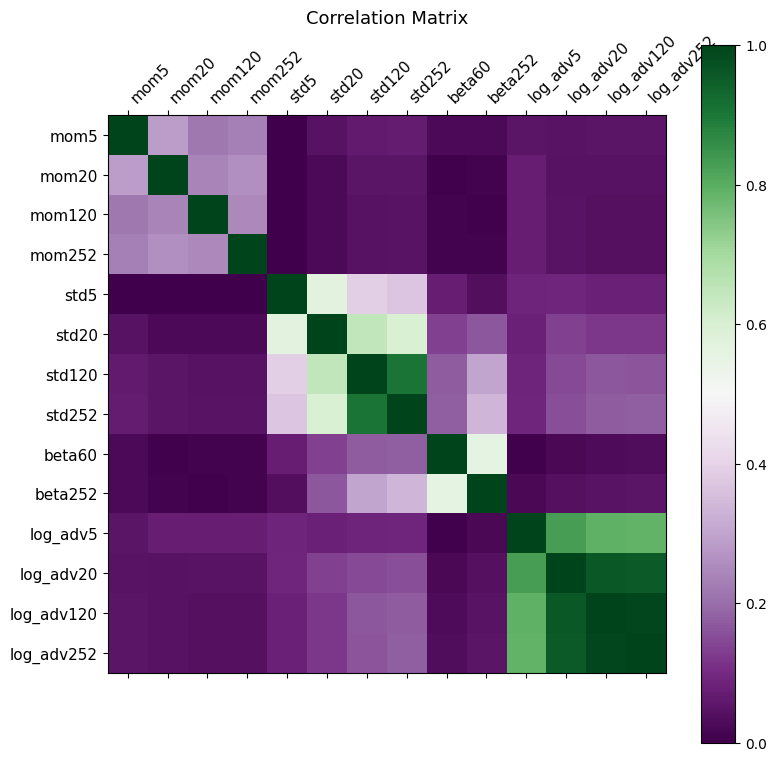

In [58]:
plot_corr_mat(Cmat, vmin=0, fs=(9, 9))

## Stability over time

In [135]:
df_mom = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('mom20').mean().alias('mom_mean'),
        c('mom20').std().alias('mom_std'),
    )
).collect().to_pandas().set_index('date')
df_std = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('std20').mean().alias('std_mean'),
        c('std20').std().alias('std_std'),
    )
).collect().to_pandas().set_index('date')

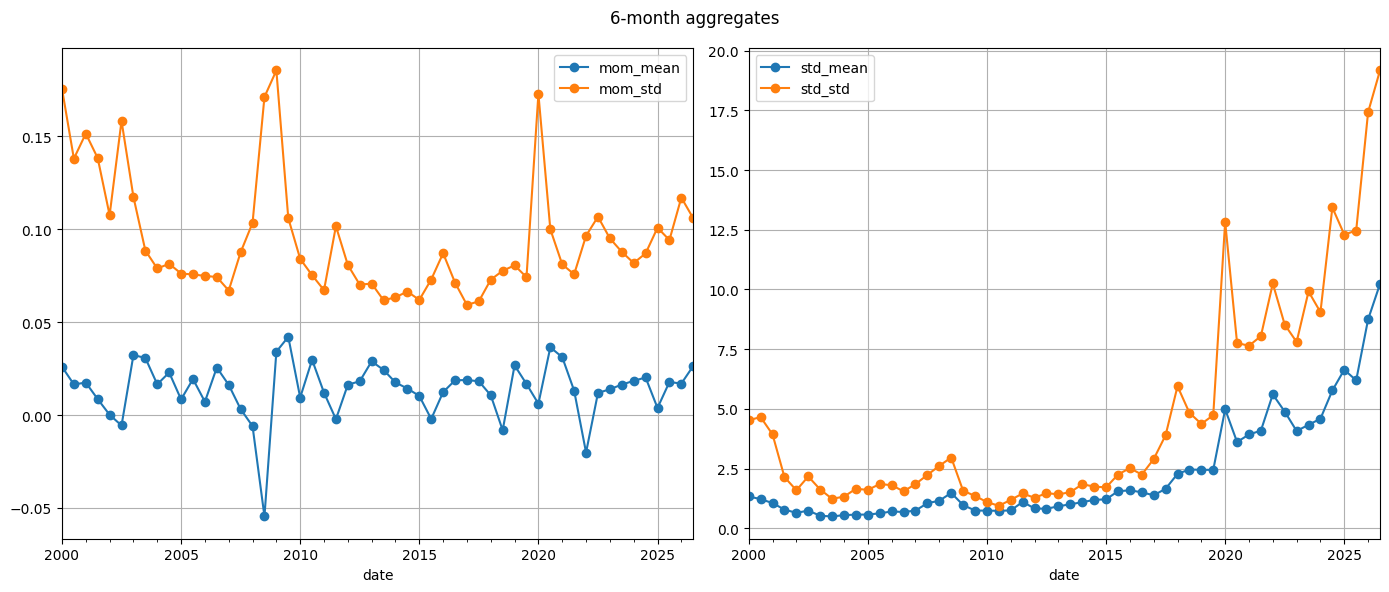

In [137]:
f, ax = plt.subplots(1, 2, figsize=(14, 6))
df_mom.plot(ax=ax[0], marker='o')
df_std.plot(ax=ax[1], marker='o')
ax[0].grid();ax[1].grid();f.suptitle('6-month aggregates');plt.tight_layout();

## QQ plots

In [138]:
df = (
    lf
    .select(['mom5', 'mom20', 'mom120', 'mom252', 
             'std5', 'std20', 'std120', 'std252', 
             'adv5', 'adv20', 'adv120', 'adv252'])
    .drop_nulls()
    .collect()
    .to_pandas()
)

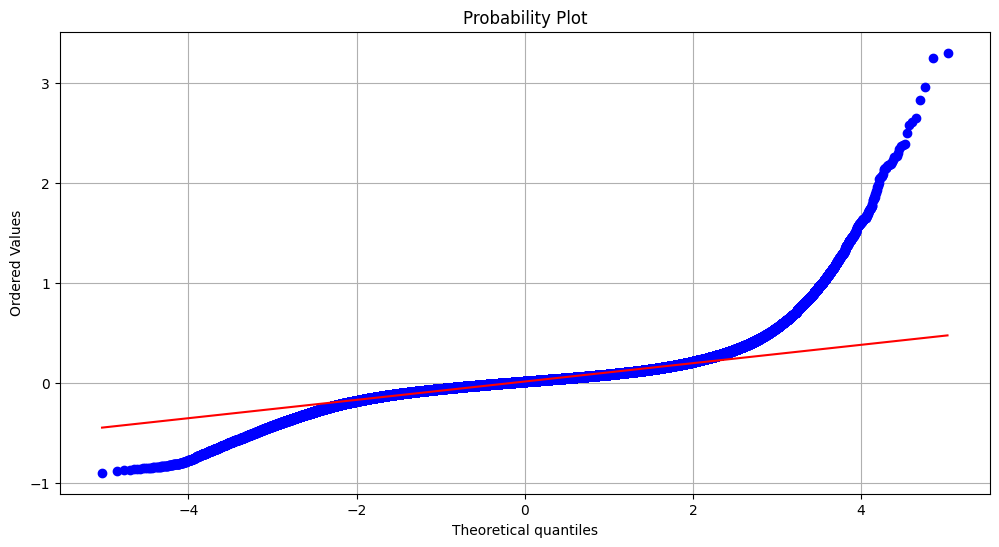

In [140]:
f, ax = new_fig()
stats.probplot(df['mom20'], plot=plt)
plt.grid()

## mom20 vs log-returns

In [59]:
df = (
    lf
    .select(
        c('date'), 
        (
            c('logret')
            .shift(-1)
            .over('ticker')
            .alias('next_logret')
        ), 
        c('mom20')
    )
    .drop_nulls()
    .collect()
    .to_pandas()
    .set_index('date')
)

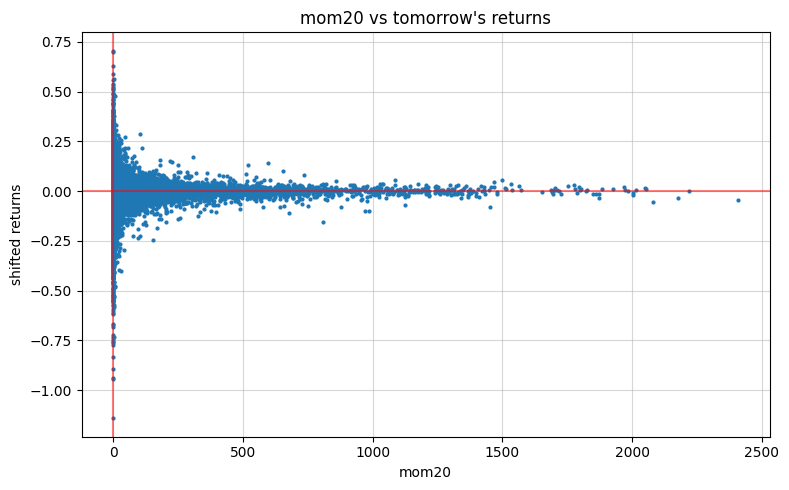

In [60]:
f, ax = new_fig(fs=(8, 5))
plt.plot(df['mom20'], df['next_logret'], 'o', markersize=2)
plt.axhline(0, color='red', alpha=0.5);plt.axvline(0, color='red', alpha=0.5)
finish_fig(ax, xl='mom20', yl='shifted returns', title='mom20 vs tomorrow\'s returns')